In [1]:
import sys
import os
sys.path.append('/project/GCRB/Hon_lab/s223695/Data_project/Perturb_seq_shared/')

import pandas as pd
import numpy as np
import scanpy as sc

from sklearn.cluster import KMeans
import scipy.stats
from scipy.stats import hypergeom
from sklearn.metrics import pairwise_distances
from itertools import combinations

from sklearn.manifold import MDS,Isomap,TSNE
from sklearn.cluster import AffinityPropagation,AgglomerativeClustering

import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({'axes.labelsize' : 'large',
                     'pdf.fonttype' : 42
                    }) 
from matplotlib.backends.backend_pdf import PdfPages

from tqdm import tqdm
from tqdm.contrib.concurrent import process_map

import gc
import warnings
import time
import pickle
import json

from sklearn.metrics import pairwise_distances
from multiprocessing import Pool
import torch

from importlib import reload
import util_functions

from adjustText import adjust_text
import umap

/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<h3>Load data</h3>

In [2]:
json_fp = "./config.json"
with open(json_fp, 'r') as fp:
    config = json.load(fp)
    input_file = config["input_data"]["input_file"]
    
sgRNA_file = config["input_data"]["sgRNA_file"]

gRNA_dict_file = config["user_defined_data"]["gRNA_dict_file"]
pca_file = config["user_defined_data"]["pca_file"]
annotation_file = config["user_defined_data"]["annotation_file"]

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

(X,gRNA_dict) = util_functions.load_files(input_file,sgRNA_file,gRNA_dict_file,pca_file)

read input
read pickle
read from dictionary


In [3]:
sgRNA_outlier_clear_df = pd.read_csv("Step1_sgRNA_outlier_pval_clear.csv",index_col=0)

In [4]:
sgRNA_outlier_clear_df.head()

,pval_outlier,target_region,target_name
chr9:130713809-130713827(+),0.9880,chr9:130713809-130714264,ABL1_ENST00000372348.2
chr9:130713821-130713839(+),0.9880,chr9:130713809-130714264,ABL1_ENST00000372348.2
chr9:130713859-130713877(+),0.9686,chr9:130713809-130714264,ABL1_ENST00000372348.2
chr9:130713979-130713997(-),0.9283,chr9:130713809-130714264,ABL1_ENST00000372348.2
chr9:130714246-130714264(-),0.9686,chr9:130713809-130714264,ABL1_ENST00000372348.2


In [5]:
clear_sgRNA_list = sgRNA_outlier_clear_df.index.tolist()

In [6]:
annotation_df = pd.read_csv(annotation_file,index_col=0)
annotation_df.head()

,guide_chr,guide_start,guide_end,score,strand,protospacer_target,intended_target_region,gene_target,source,closest_gene,closest_dist,closest_gene_target,closest_dist_target
0,chr9,130713821,130713839,.,+,chr9:130713821-130713839(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,56,ABL1,56
1,chr9,130713809,130713827,.,+,chr9:130713809-130713827(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,56,ABL1,56
2,chr9,130713859,130713877,.,+,chr9:130713859-130713877(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,56,ABL1,56
3,chr9,130714246,130714264,.,-,chr9:130714246-130714264(-),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,56,ABL1,56
4,chr9,130713865,130713883,.,+,chr9:130713865-130713883(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,56,ABL1,56


In [7]:
gRNA_region_dict = {}

OR_gRNA_list = [i for i in gRNA_dict.keys() if i.startswith("OR")]

for gRNA_tmp in OR_gRNA_list:
    gene_name = gRNA_tmp.split("-")[0]
    
    if gene_name in gRNA_region_dict.keys():
        gRNA_region_dict[gene_name] += [gRNA_tmp]
    else:
        gRNA_region_dict[gene_name] = [gRNA_tmp]

        
for target in np.unique(sgRNA_outlier_clear_df["target_region"]):
    gRNA_region_dict[target] = sgRNA_outlier_clear_df[sgRNA_outlier_clear_df["target_region"]==target].index.to_list()
    gRNA_region_dict[target] = np.unique(gRNA_region_dict[target])

In [8]:
cell_per_region_dict = {}
for key in gRNA_region_dict.keys():
    cell_list_tmp = np.concatenate([gRNA_dict[i] for i in gRNA_region_dict[key]])
    cell_per_region_dict[key] = np.unique(cell_list_tmp)

In [9]:
pval_df = pd.read_csv("Step2_pval_target.csv",index_col=0)
pval_df_sig = pd.read_csv("Step2_pval_target_significant.csv",index_col=0)

<h3>Aggregate by target</h3>

In [10]:
pval_df.head()

,distance_0,pval_0,distance_1,pval_1,distance_2,pval_2,distance_3,pval_3,distance_4,pval_4,...,pval_19,pval_mean,pval_std,distance_mean,distance_std,pval_mean_log,distance_mean_log,region_name,source,is_enhancer
OR10G4,4.309937,0.019,4.863525,0.004,4.076660,0.015,2.286987,0.204,4.128052,0.017,...,0.058,0.03800,0.054145,4.246948,1.180880,1.420102,0.628077,OR10G4,Control,False
OR10H2,1.420410,0.652,1.601074,0.523,1.448120,0.654,1.128784,0.855,1.378418,0.686,...,0.816,0.66225,0.238118,1.441760,0.473596,0.178971,0.158893,OR10H2,Control,False
OR10H5,12.558105,0.000,13.742798,0.000,11.319946,0.000,9.702148,0.000,11.939331,0.000,...,0.000,0.00000,0.000000,12.162756,1.705439,5.000000,1.085032,OR10H5,Control,False
OR10K1,1.624512,0.634,1.484863,0.680,2.174927,0.339,1.305908,0.785,1.566772,0.678,...,0.705,0.58415,0.238986,1.753357,0.554499,0.233468,0.243870,OR10K1,Control,False
OR10P1,4.771973,0.014,4.610718,0.024,5.093262,0.011,3.394165,0.091,4.644043,0.018,...,0.014,0.03335,0.038007,4.666467,1.001044,1.476774,0.668988,OR10P1,Control,False


In [11]:
region_list = np.unique(pval_df["region_name"])
region_list = [x for x in region_list if not x.startswith("OR")]

region_list_sig = np.unique(pval_df_sig["region_name"])
region_list_sig = [x for x in region_list_sig if not x.startswith("OR")]

<h3>make energy dist map of significant hits</h3>

In [12]:
cell_id_list_target = []
for target in region_list:
    sgRNA_names = sgRNA_outlier_clear_df[sgRNA_outlier_clear_df["target_name"]==target].index.to_list()

    cell_id_total = np.concatenate([gRNA_dict[name] for name in sgRNA_names])
    cell_id_total = np.unique(cell_id_total)
    cell_id_list_target += [cell_id_total]
    
print(len(cell_id_list_target))

1539


In [13]:
!nvidia-smi

/bin/bash: nvidia-smi: コマンドが見つかりません


In [14]:
len(cell_id_list_target)
cell_num_dist = [len(x) for x in cell_id_list_target]

<Axes: ylabel='Count'>

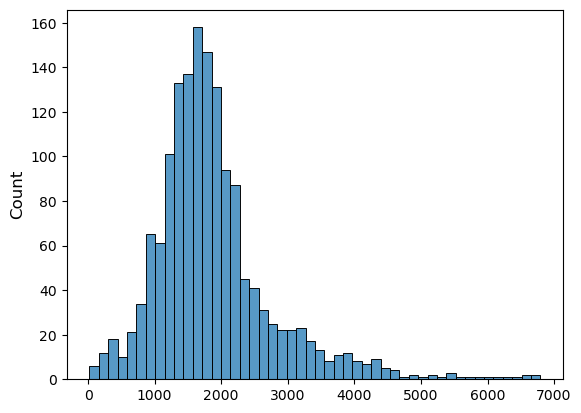

In [15]:
sns.histplot(cell_num_dist)

In [16]:
combi = list(combinations(range(len(cell_id_list_target)),2)) + \
        [(x,x) for x in range(len(cell_id_list_target))]

In [17]:
downsampling = config["aggregate"]["downsampling_maximum"]
res = []

pbar=tqdm(combi)
for target1_idx, target2_idx in pbar:
    pbar.set_postfix({"target1":region_list[target1_idx],
                      "target2":region_list[target2_idx],
                      "mode": "GPU"
                     })
    cell_test1 = cell_id_list_target[target1_idx]
    cell_test2 = cell_id_list_target[target2_idx]
    
    if len(cell_test1) > downsampling:
        cell_test1 = cell_test1[:downsampling]
    if len(cell_test2) > downsampling:
        cell_test2 = cell_test2[:downsampling]
    
    try:
        obs_edist = util_functions.permutation_test(X,cell_test1,cell_test2,device,batch_num=1,total_permute=1,
                                                    return_permute=False).item()
    except:
        try:
            pbar.set_postfix({"target1":region_list[target1_idx],
                              "target2":region_list[target2_idx],
                              "mode": "CPU"
                             })
            obs_edist = util_functions.permutation_test(X,cell_test1,cell_test2,"cpu",batch_num=1,total_permute=1,
                                                        return_permute=False).item()
        except:
            print("data too large",region_list[target1_idx],region_list[target2_idx])
            obs_edist=-1
            continue
    res += [(region_list[target1_idx],region_list[target2_idx],obs_edist)]

  1%|          | 7358/1185030 [01:26<4:02:15, 81.02it/s, target1=ADAMTS10_P1P2, target2=Element911, mode=GPU]                        Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x2aaab4dbe000>>
Traceback (most recent call last):
  File "/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 770, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 
  1%|          | 7489/1185030 [01:27<3:50:13, 85.25it/s, target1=ADAMTS10_P1P2, target2=HAND2_P1, mode=GPU]   

KeyboardInterrupt



In [ ]:
pairwise_dict=dict(zip(region_list,[" "]*len(region_list)))
for key in pairwise_dict.keys():
    pairwise_dict[key] = dict(zip(region_list,[" "]*len(region_list)))

for p1, p2, val in tqdm(res):
    
    pairwise_dict[p1][p2]=val
    pairwise_dict[p2][p1]=val
target_estats = pd.DataFrame(pairwise_dict,index=region_list,columns=region_list) 

In [ ]:
target_estats

In [ ]:
target_estats_sig = target_estats.loc[np.isin(region_list,region_list_sig),
                                      np.isin(region_list,region_list_sig)]

In [ ]:
target_estats.to_csv("Step3_target_by_target_matrix.csv")
target_estats_sig.to_csv("Step3_target_by_target_matrix_significant.csv")

In [ ]:
sns.clustermap(target_estats_sig,figsize=(80,80),vmax=100)
plt.savefig("Step3_target_by_target_matrix.pdf")

<h3>Use the best clustering parameter +visualization </h3>

In [20]:
target_estats_sig= pd.read_csv("Step3_target_by_target_matrix_significant.csv",index_col=0)

In [22]:
fit_method_for_cluster = Isomap(n_neighbors=2, n_components=60, metric="precomputed")
embedding_for_cluster = fit_method_for_cluster.fit_transform(target_estats_sig.copy())

clustering_method_emb = AffinityPropagation(random_state=0,convergence_iter=15,damping=0.50)

cluster_info_emb = clustering_method_emb.fit(embedding_for_cluster)

/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/site-packages/sklearn/manifold/_isomap.py:383: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/site-packages/scipy/sparse/_index.py:102: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])


In [23]:
fit_method = TSNE(n_components=2, perplexity=2,n_iter=5000,random_state=1,
                  init="random",metric="precomputed")

embedding = fit_method.fit_transform(target_estats_sig.copy())
# fit_method = TSNE(n_components=2, perplexity=2,n_iter=5000,random_state=1,
#                   init="random")
# embedding = fit_method.fit_transform(embedding_for_cluster)


total_edist_umap=pd.DataFrame(embedding,index=target_estats_sig.index,columns=["x","y"]).reset_index()
# total_edist_umap["cluster"]=cluster_info.labels_
total_edist_umap["cluster"]=cluster_info_emb.labels_

In [24]:
total_edist_umap

,index,x,y,cluster
0,ACTN2_P1P2,19.373337,27.999640,7
1,ACVR2B_P1P2,-30.474840,-67.610649,4
2,ADNP2_P1P2,111.833244,-42.315434,6
3,AFF4_P1P2,59.983475,-50.508873,16
4,BMPR2_P1P2,86.653328,-36.387592,25
...,...,...,...,...
302,ZNF460_P1P2,99.046448,-4.895367,0
303,ZNF649_P1P2,-62.926304,-25.884039,17
304,ZNF787_P1P2,79.313484,-36.040760,0
305,ZNF814_P1P2,-50.758381,10.807098,17


In [25]:
for cluster_index in np.unique(total_edist_umap["cluster"]):
    print(cluster_index,total_edist_umap[total_edist_umap["cluster"]==cluster_index]["index"].tolist())

0 ['BPTF_P1P2', 'CHD7_P1P2', 'Element185', 'Element739', 'FGFR2_P1P2', 'FOXC1_P1P2', 'MEF2A_P1P2', 'MESP1_P1P2', 'PLAGL2_P1P2', 'RNF2_P1P2', 'ZNF460_P1P2', 'ZNF787_P1P2']
1 ['EOMES_P1P2']
2 ['Element1018', 'SMAD5_P1P2']
3 ['Element109', 'Element1167', 'FOXD3_P1', 'FOXD3_P2', 'GTF2I_P1P2', 'PCGF6_P1P2']
4 ['ACVR2B_P1P2', 'Element1090', 'Element895', 'HMG20A_P1P2', 'L3MBTL3_P1P2']
5 ['Element1099']
6 ['ADNP2_P1P2', 'CHAMP1_P1P2', 'Element1035', 'Element1194', 'Element321', 'Element36', 'Element997', 'MEF2D_P1P2', 'PCGF2_P1', 'SHOC2_P1P2']
7 ['ACTN2_P1P2', 'BNC1_P1P2', 'Element1011', 'Element1110', 'Element1127', 'Element1138', 'Element1148', 'Element1150', 'Element1163', 'Element1230', 'Element1234', 'Element1235', 'Element1239', 'Element1254', 'Element1257', 'Element162', 'Element173', 'Element192', 'Element204', 'Element211', 'Element215', 'Element241', 'Element25', 'Element273', 'Element278', 'Element297', 'Element298', 'Element361', 'Element399', 'Element409', 'Element435', 'Element4

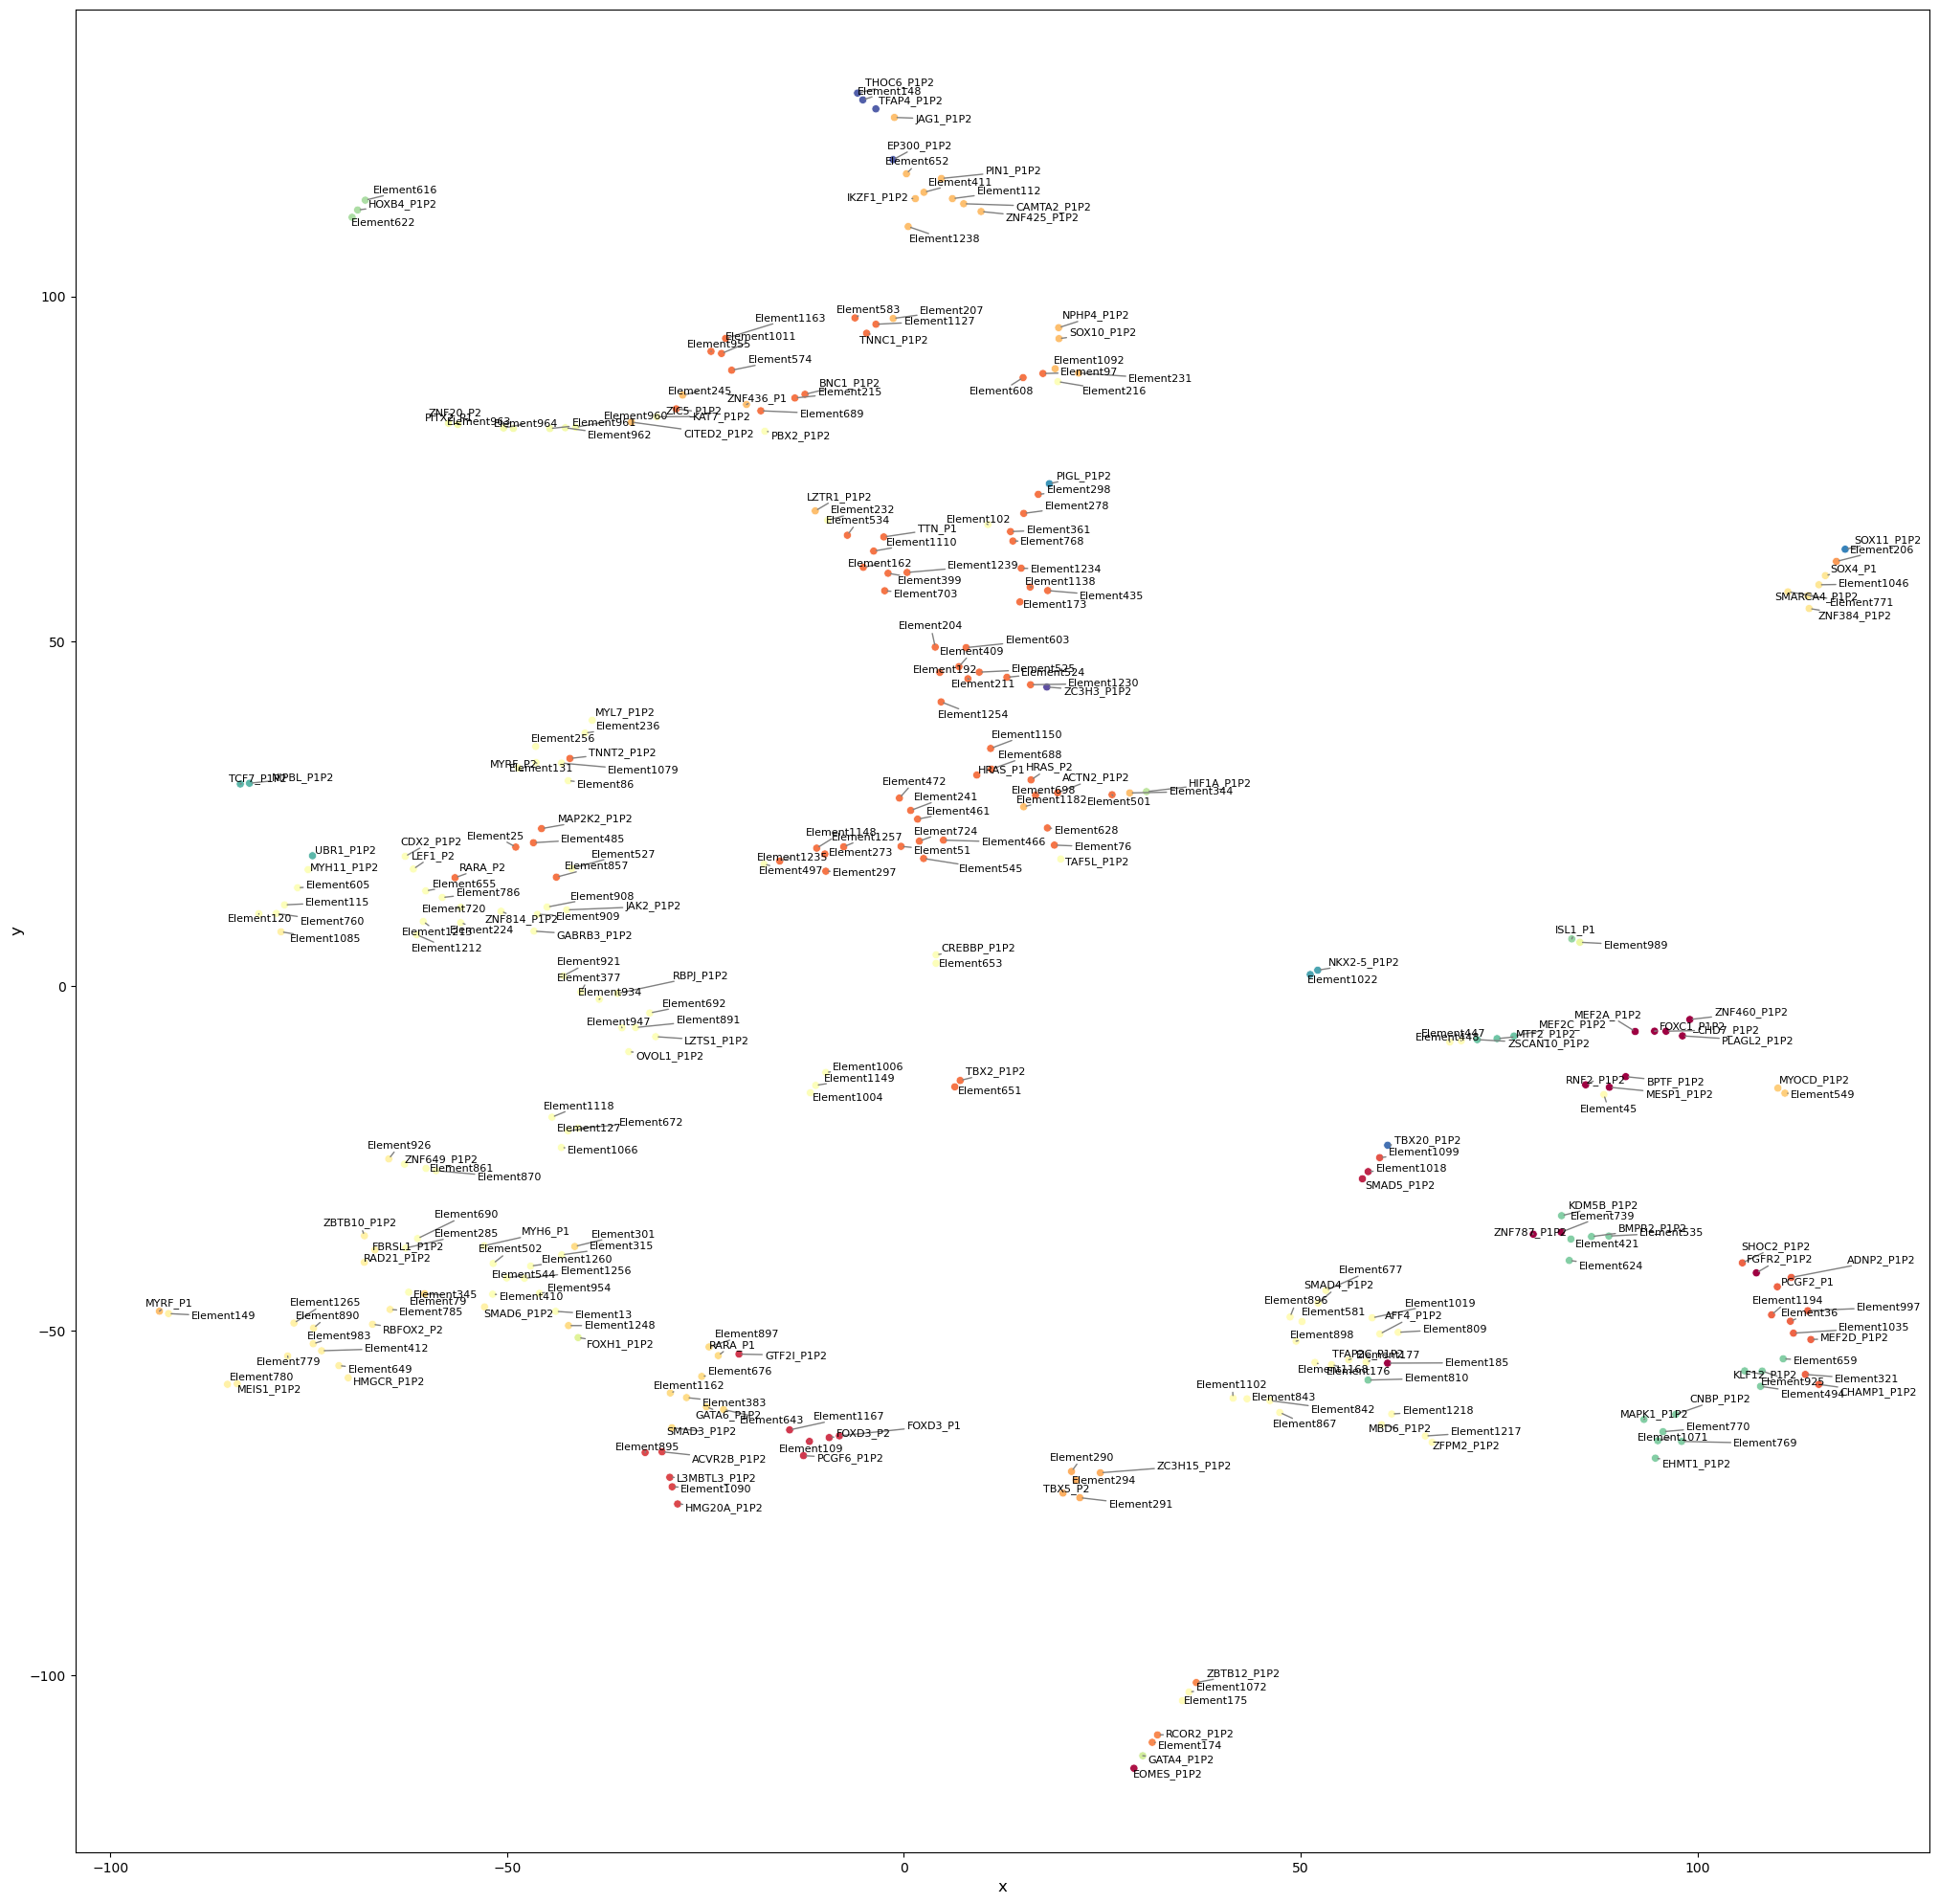

In [29]:
total_edist_umap_tmp = total_edist_umap.copy()

fig,ax= plt.subplots(figsize=(25,25)) 

sns.scatterplot(data=total_edist_umap_tmp,x="x",y="y",ax=ax,hue="cluster",
                palette=sns.color_palette("Spectral", as_cmap=True),legend=None)
texts = []
for index,row in total_edist_umap_tmp.iterrows():
    plt_text = ax.annotate(row["index"], (row["x"], row["y"]), fontsize=8, color='black')   
    texts.append(plt_text)
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=1),force_text=(0.3, 0.3))
plt.savefig("Step3_target_2Demb_tsne.pdf")

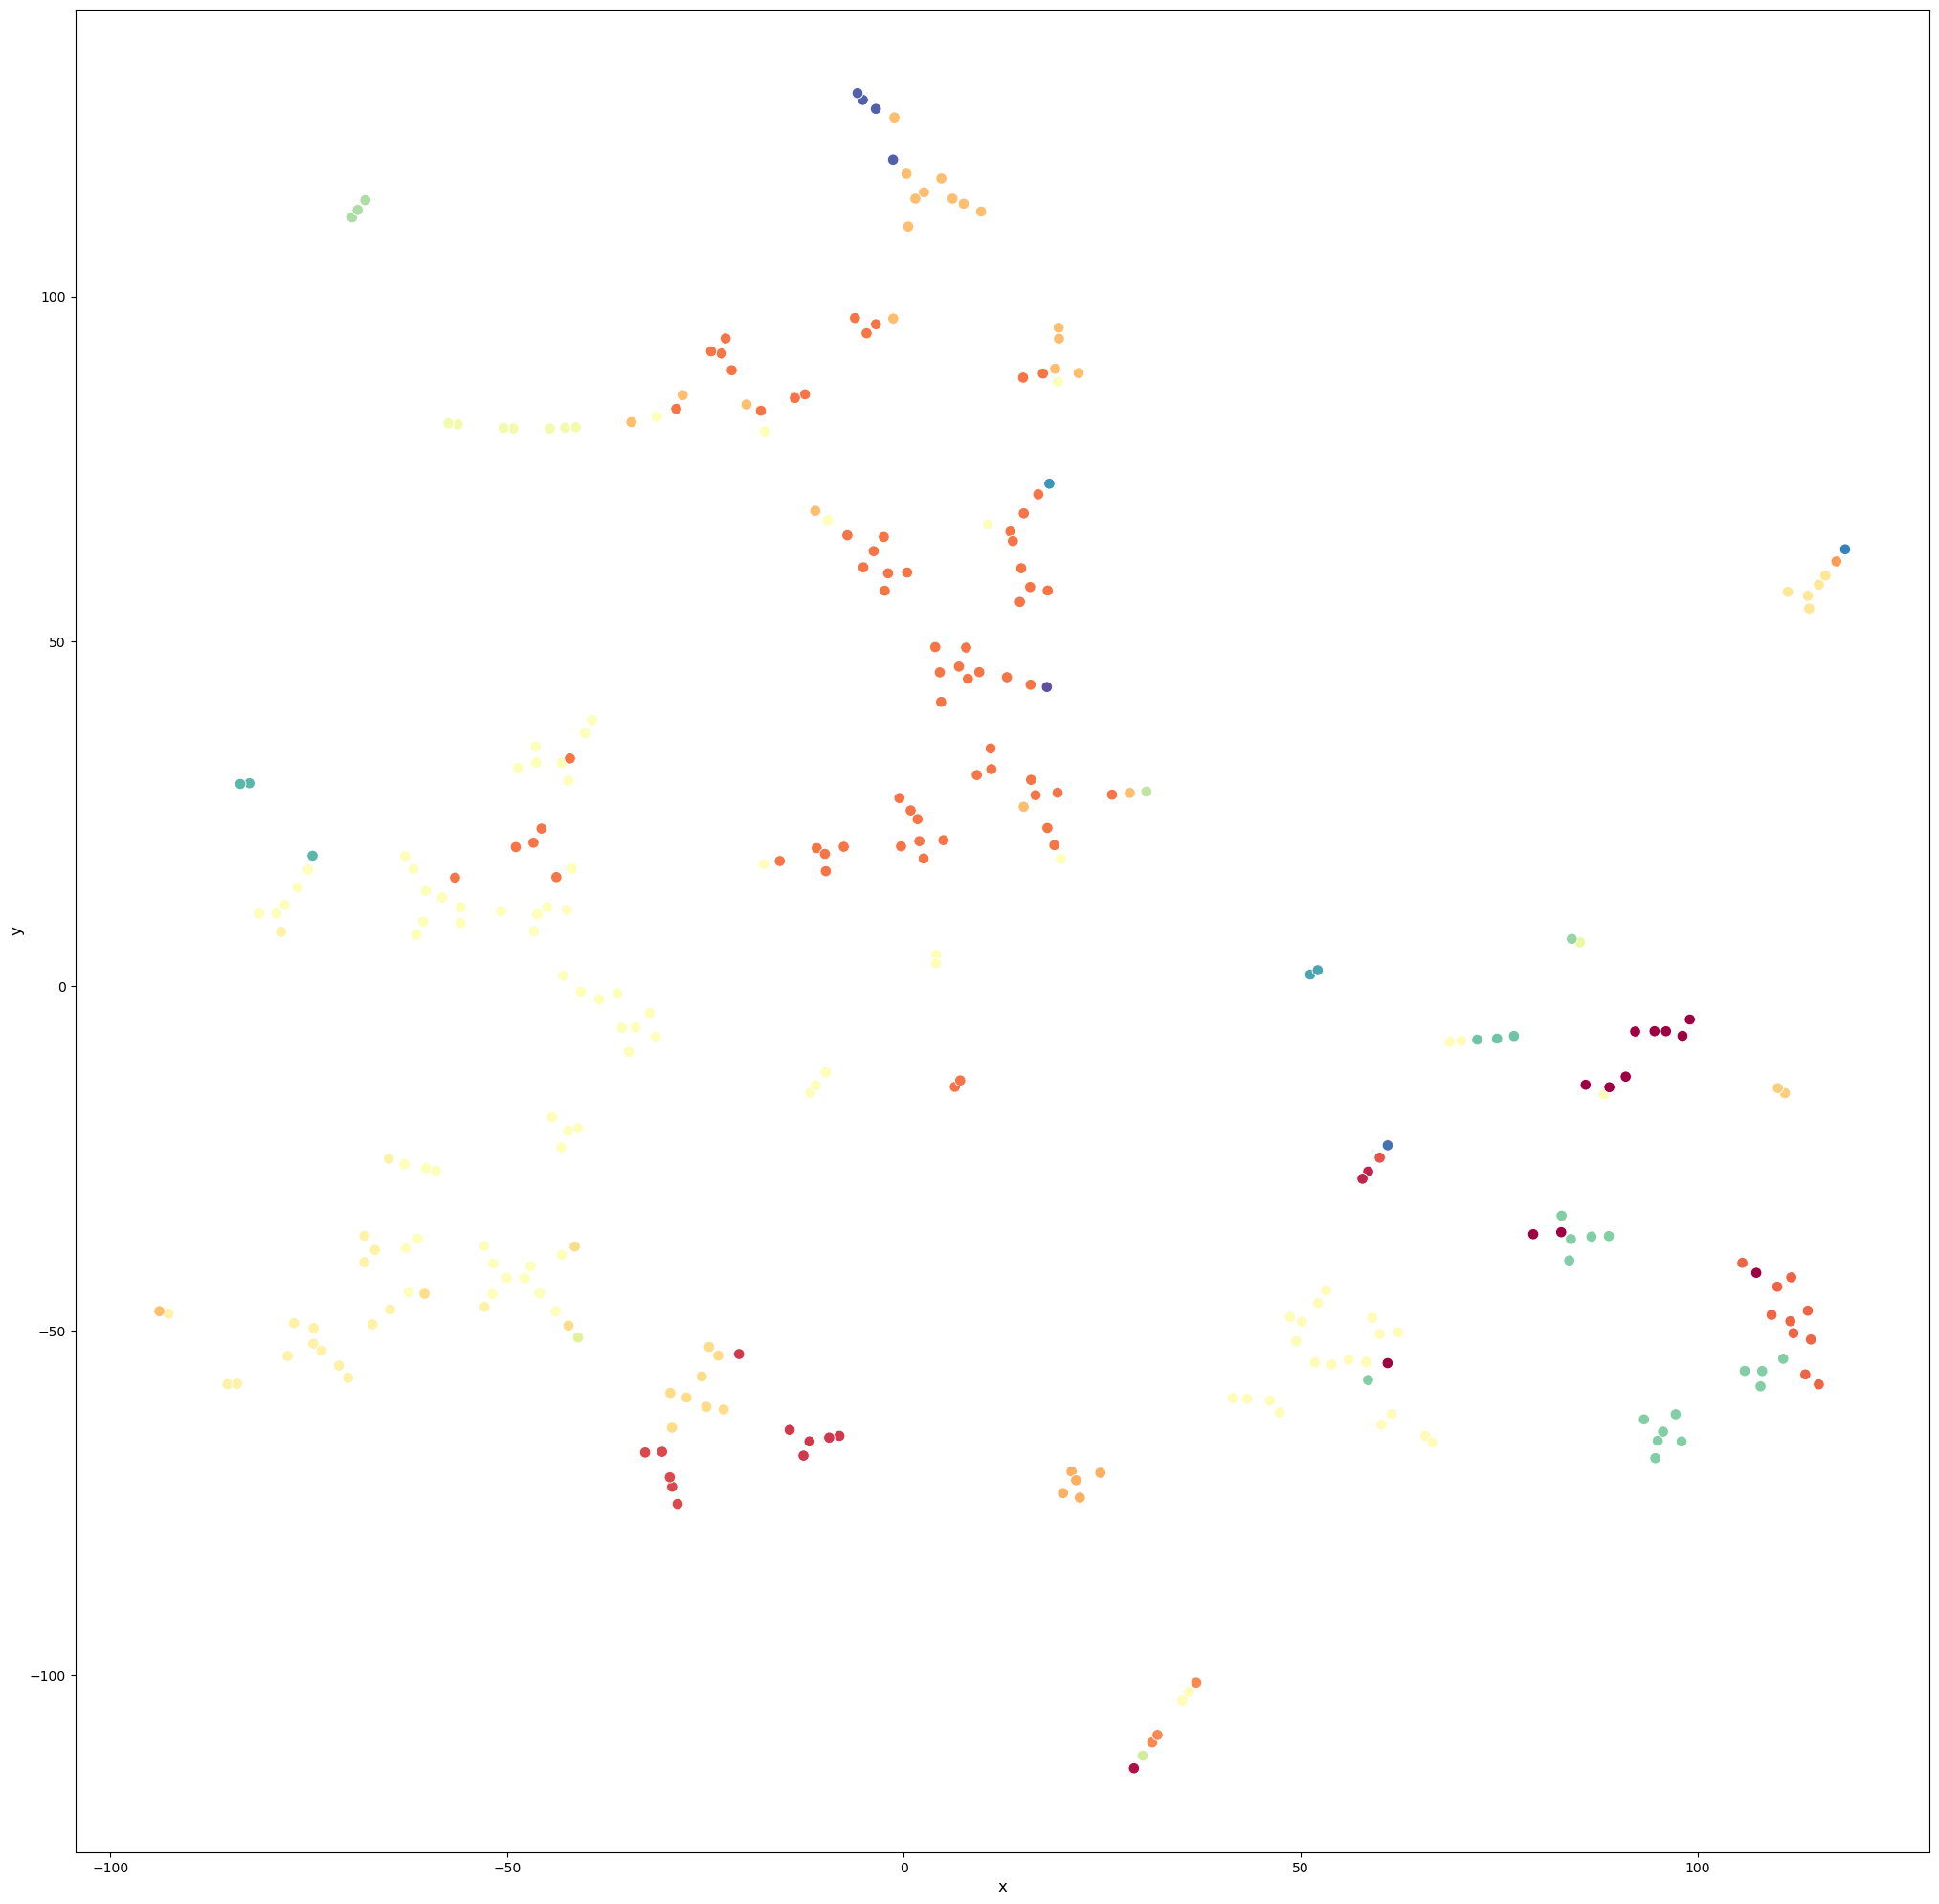

In [37]:
total_edist_umap_tmp = total_edist_umap.copy()

fig,ax= plt.subplots(figsize=(25,25)) 

sns.scatterplot(data=total_edist_umap_tmp,x="x",y="y",ax=ax,hue="cluster",s=70,
                palette=sns.color_palette("Spectral", as_cmap=True),legend=None)

plt.savefig("Step3_target_2Demb_tsne_wo_text.pdf")

In [31]:
total_edist_umap.to_csv("Step3_target_2Demb_tsne_data.csv")